In [7]:
import preprocess as pp 
import calibration as cb 
import shortestpath as sp 
import pandas as pd
import geopandas as gpd
import os

In [8]:
evac = gpd.read_file('./poi/Kochi_EvacBldg_CRS4326.geojson')

In [9]:
points = gpd.read_file('./poi/centerpoints.shp')
points = points.to_crs(epsg=4326)
points.head()

,id,geometry
0,0,POINT (133.54184 33.49106)


In [10]:
case = 'usama' #use names in 'areas' dictionary

areas = {
    'usama' : (33.49106,133.54184),
    'ishinomaki': (38.4259826,141.3012349),
    'otaru' : (43.1908875, 140.9951859), 
    'kochi' : (33.5581452, 133.5319937), 
    'noto' : (37.3910308,136.9047961),  
    'sumatra' : (5.5485879, 95.3137873),
    'peru' : (-12.0716443,-77.1622644) 
}

#these are OSM node ids
shelters = {'usama' : [1557771076, 4942039738, 1431985105],
            'ishinomaki' : [2166925996],
            'otaru' : [1644237911],
            'kochi' : [5303394931],
            'noto' : [11494769981],
            'sumatra' : [764419156],
            'peru' : [3042136183]
}

pop = {  'usama' : 3000,
         'ishinomaki' : 3703,
         'otaru' : 5684,
         'kochi' : 2619,
         'noto' : 2507,
         'sumatra' : 3208,
         'peru' : 5105
    }

In [11]:
times_population = [1]
pp.main(areas=areas, foldername=case, evacnodes=shelters[case], times=times_population, pop=pop[case], multi=True, use_seed=False, sp=True) 

rm: ./usama_CAREFUL_PREVIOUS_INPUT: No such file or directory


Folder usama created
Graph downloaded
Node 1557771076 is an evacuation node
Node 4942039738 is an evacuation node
Node 1431985105 is an evacuation node
Short links removed, nodes merged, counters updated, and link references adjusted successfully.
Population in file: 3000


survived pedestrians: 2824


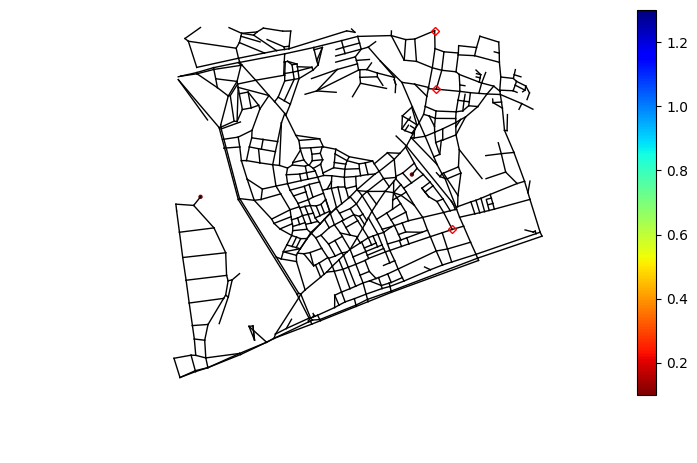

In [12]:
# Run Shortest Path
simulTime = 30*60
meanrayleigh = 5
   
for t in times_population:
    sp.run(foldername=case, timeSimulation=simulTime, popfile=t, meanrayleigh=meanrayleigh, video=False)